# Construcción de ratios financieros e índice de riesgo crediticio

**Objetivo:** estimar la solidez crediticia relativa de cinco emisores colombianos del sector energía e infraestructura (ISA, ISAGEN, EPM, CELSIA, ENEL Colombia) mediante un índice compuesto de ratios financieros y dos escenarios de estrés.

**Insumo:** `panel_limpio.csv` — datos trimestrales de EEFF bajo NIIF extraídos desde XBRL del RNVE (Superfinanciera), periodo 2021Q1–2026Q2.

**Metodología:** ratios TTM (trailing twelve months) → normalización por z-score → índice ponderado → stress testing operativo y de tasas.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path

plt.style.use("seaborn-v0_8-whitegrid")
COLORS = {
    "CELSIA":  "#E8703A",
    "ENEL":    "#2C4770",
    "EPM":     "#3A9E8F",
    "ISA":     "#C94040",
    "ISAGEN":  "#7B5EA7",
}
EMISORES = ["CELSIA", "ENEL", "EPM", "ISA", "ISAGEN"]

df = pd.read_csv("../Data/processed/panel_limpio.csv")
df["periodo"] = df["periodo"].astype(str)
df = df.sort_values(["emisor", "periodo"]).reset_index(drop=True)

print("Panel cargado:", df.shape)
print(df.groupby("emisor")["periodo"].agg(["count", "min", "max"]))

Panel cargado: (109, 9)
        count     min     max
emisor                       
CELSIA     22  2021Q1  2026Q2
ENEL       21  2021Q2  2026Q2
EPM        22  2021Q1  2026Q2
ISA        22  2021Q1  2026Q2
ISAGEN     22  2021Q1  2026Q2


In [2]:
FLUJOS = ["ebitda", "gastos_financieros", "ingresos"]
STOCKS = ["deuda_cp", "deuda_lp", "caja"]

def calcular_ttm(df: pd.DataFrame) -> pd.DataFrame:
    """Suma los últimos 4 trimestres para flujos; conserva stock puntual."""
    frames = []
    for emisor, grupo in df.groupby("emisor"):
        grupo = grupo.sort_values("periodo").copy()
        for col in FLUJOS:
            grupo[f"{col}_ttm"] = grupo[col].rolling(4, min_periods=4).sum()
        for col in STOCKS:
            grupo[f"{col}_ttm"] = grupo[col]
        if "ebitda_imputado" in grupo.columns:
            grupo["ebitda_imputado_ttm"] = grupo["ebitda_imputado"].rolling(4).sum() > 0
        else:
            grupo["ebitda_imputado_ttm"] = False
        frames.append(grupo)
    return pd.concat(frames, ignore_index=True)

ttm = calcular_ttm(df)
ttm = ttm.dropna(subset=[f"{c}_ttm" for c in FLUJOS]).copy()
ttm = ttm.sort_values(["emisor", "periodo"]).reset_index(drop=True)

print(f"Observaciones TTM disponibles: {len(ttm)}")
print(ttm.groupby("emisor")["periodo"].agg(["count", "min", "max"]))

Observaciones TTM disponibles: 94
        count     min     max
emisor                       
CELSIA     19  2021Q4  2026Q2
ENEL       18  2022Q1  2026Q2
EPM        19  2021Q4  2026Q2
ISA        19  2021Q4  2026Q2
ISAGEN     19  2021Q4  2026Q2


## Ventana TTM

El análisis usa ventanas TTM (trailing twelve months): para cada trimestre, se suman los cuatro trimestres anteriores de flujos (EBITDA, gastos financieros, ingresos) y se conserva el saldo puntual de los stocks (caja, deuda). Esto elimina la estacionalidad y hace comparables los ratios a lo largo del tiempo.

El panel original tiene entre 21 y 22 trimestres por emisor. La ventana TTM consume los primeros 3 trimestres de cada serie, dejando entre 18 y 19 observaciones válidas por emisor (desde 2021Q4 o 2022Q1).

**Nota sobre ENEL:** el EBITDA de los trimestres Q2–Q4 de cada año se imputó con el margen EBITDA promedio de los cinco periodos Q1 observados directamente. Este supuesto se mantiene constante a lo largo del análisis y se documenta como limitación.

In [3]:
# Deuda CP puede ser cero para algunos emisores (ENEL); se reemplaza por NaN
# para evitar divisiones por cero en liquidez_cp
ttm["deuda_total_ttm"] = ttm["deuda_cp_ttm"] + ttm["deuda_lp_ttm"]

ttm["deuda_ebitda"]        = ttm["deuda_total_ttm"] / ttm["ebitda_ttm"]
ttm["cobertura_intereses"] = ttm["ebitda_ttm"] / ttm["gastos_financieros_ttm"]
ttm["liquidez_cp"]         = ttm["caja_ttm"] / ttm["deuda_cp_ttm"].replace(0, np.nan)
ttm["margen_ebitda"]       = ttm["ebitda_ttm"] / ttm["ingresos_ttm"]

RATIOS = ["deuda_ebitda", "cobertura_intereses", "liquidez_cp", "margen_ebitda"]

print("Ratios promedio por emisor (ventana TTM completa):")
print(ttm.groupby("emisor")[RATIOS].mean().round(2))

print("\nRatios último periodo disponible:")
print(
    ttm.sort_values("periodo")
       .groupby("emisor")[RATIOS + ["periodo"]]
       .last()
       .round(2)
)

Ratios promedio por emisor (ventana TTM completa):
        deuda_ebitda  cobertura_intereses  liquidez_cp  margen_ebitda
emisor                                                               
CELSIA          4.35                 1.98         0.31           0.21
ENEL            1.33                 6.45         0.99           0.46
EPM             2.20                 3.04         1.12           0.24
ISA             4.27                 3.21         2.13           0.54
ISAGEN          4.82                 1.86         0.59           0.54

Ratios último periodo disponible:
        deuda_ebitda  cobertura_intereses  liquidez_cp  margen_ebitda periodo
emisor                                                                       
CELSIA          5.07                 1.58         0.29           0.17  2026Q2
ENEL            1.23                 5.96         1.84           0.47  2026Q2
EPM             1.63                 2.98         1.46           0.29  2026Q2
ISA             4.43              

## Interpretación de los cuatro ratios

### Deuda / EBITDA
Cuántos años de generación operativa de caja necesitaría cada empresa para cubrir su deuda total. Valor más alto implica mayor apalancamiento. **ISAGEN** lidera el riesgo de apalancamiento con 4.82x de promedio, seguido de **CELSIA** (4.35x) e **ISA** (4.27x). **ENEL** presenta el menor nivel (1.33x), consistente con su perfil de distribuidora regulada con flujos estables. **EPM** queda en posición intermedia (2.20x).

### Cobertura de intereses (EBITDA / Gastos financieros)
Cuántas veces el EBITDA cubre el servicio de intereses. Valor más alto es más seguro. **ENEL** tiene la cobertura más holgada (6.45x), lo que indica bajo riesgo de impago de intereses en el corto plazo. **ISAGEN** (1.86x) y **CELSIA** (1.98x) muestran la señal más preocupante: su EBITDA apenas duplica los gastos financieros, dejando poco margen ante un choque operativo. El ratio de **ISAGEN** en particular combina alto apalancamiento con baja cobertura, una combinación de riesgo doble.

### Liquidez de corto plazo (Caja / Deuda CP)
Capacidad de atender vencimientos de corto plazo con caja disponible. **ISA** presenta el mayor colchón de liquidez (2.13x), seguida de **EPM** (1.12x). **CELSIA** (0.31x) tiene el menor margen de liquidez del grupo, lo que lo hace más vulnerable a un cierre de mercados de refinanciamiento. Para **ENEL**, el ratio debe interpretarse con cautela porque su deuda CP es mínima en la mayor parte de la historia.

### Margen EBITDA
Qué fracción de los ingresos se convierte en EBITDA. Captura eficiencia operativa. **ISA** e **ISAGEN** tienen el margen más alto (54%), consistente con activos de infraestructura de transmisión y generación de bajo costo variable. **CELSIA** (21%) tiene el menor margen, posiblemente por mayor exposición a generación térmica de respaldo en años secos.

In [4]:
# Normalización: z-score dentro del panel TTM completo
# deuda_ebitda invertida (más alto = más riesgo → multiplicar por -1)
panel_ratios = ttm[["emisor", "periodo"] + RATIOS + ["ebitda_imputado_ttm"]].copy()

PESOS = {
    "deuda_ebitda":        0.30,   # apalancamiento
    "cobertura_intereses": 0.30,   # cobertura
    "liquidez_cp":         0.20,   # liquidez
    "margen_ebitda":       0.20,   # rentabilidad
}

PARAMS = {}  # guardamos mu y sigma para reutilizar en stress

for ratio in RATIOS:
    mu    = panel_ratios[ratio].mean()
    sigma = panel_ratios[ratio].std()
    PARAMS[ratio] = (mu, sigma)
    z = (panel_ratios[ratio] - mu) / sigma
    panel_ratios[f"z_{ratio}"] = -z if ratio == "deuda_ebitda" else z

panel_ratios["indice"] = sum(
    panel_ratios[f"z_{ratio}"] * peso
    for ratio, peso in PESOS.items()
)

print("Índice promedio por emisor (señal histórica):")
print(
    panel_ratios.groupby("emisor")["indice"]
    .mean()
    .sort_values(ascending=False)
    .round(3)
)

print("\nÍndice último periodo:")
print(
    panel_ratios.sort_values("periodo")
    .groupby("emisor")[["periodo", "indice"]]
    .last()
    .sort_values("indice", ascending=False)
    .round(3)
)

Índice promedio por emisor (señal histórica):
emisor
ENEL      1.006
ISA       0.280
EPM       0.026
ISAGEN   -0.434
CELSIA   -0.825
Name: indice, dtype: float64

Índice último periodo:
       periodo  indice
emisor                
ENEL    2026Q2   1.175
ISA     2026Q2   0.455
EPM     2026Q2   0.280
ISAGEN  2026Q2  -0.689
CELSIA  2026Q2  -1.087


## Normalización e índice compuesto

Cada ratio se transforma a z-score usando la media y desviación estándar de todo el panel TTM (todos los emisores y periodos juntos). Esto permite comparar dimensiones con unidades distintas sobre una escala común.

El signo de `deuda_ebitda` se invierte antes de ponderar, de modo que **un índice más alto siempre significa menor riesgo relativo**.

Los pesos reflejan la jerarquía de riesgo crediticio: apalancamiento y cobertura pesan 60% en conjunto porque son los predictores más directos de incumplimiento; liquidez y margen suman el 40% restante.

**Resultados del índice promedio histórico:**
- **ENEL (1.006):** sistemáticamente la empresa más sólida del grupo. Bajo apalancamiento y alta cobertura compensan cualquier debilidad en liquidez o margen.
- **ISA (0.280):** segunda posición, impulsada principalmente por alta liquidez y márgenes amplios, a pesar de apalancamiento elevado.
- **EPM (0.026):** en el promedio del panel, con posición más equilibrada entre dimensiones.
- **ISAGEN (−0.434):** por debajo del promedio histórico, refleja la combinación de alto apalancamiento y baja cobertura de intereses.
- **CELSIA (−0.825):** la posición más débil del grupo en términos relativos, presionada por bajo margen, baja liquidez de corto plazo y apalancamiento elevado.

In [5]:
# ── Stress test 1: caída de EBITDA del 20% ──
# Simula un año Niño fuerte que contrae la generación hidráulica
# y comprime márgenes operativos en generadoras (ISAGEN, CELSIA, EPM, ENEL)
CAIDA_EBITDA = 0.20

ultimo = (
    ttm.sort_values("periodo")
       .groupby("emisor")
       .last()
       .reset_index()
)

stress_ebitda = ultimo.copy()
stress_ebitda["ebitda_stress"]              = stress_ebitda["ebitda_ttm"] * (1 - CAIDA_EBITDA)
stress_ebitda["deuda_ebitda_stress"]        = stress_ebitda["deuda_total_ttm"] / stress_ebitda["ebitda_stress"]
stress_ebitda["cobertura_intereses_stress"] = stress_ebitda["ebitda_stress"] / stress_ebitda["gastos_financieros_ttm"]
stress_ebitda["liquidez_cp_stress"]         = stress_ebitda["liquidez_cp"]   # no cambia
stress_ebitda["margen_ebitda_stress"]       = stress_ebitda["ebitda_stress"] / stress_ebitda["ingresos_ttm"]

RATIOS_STRESS = [r + "_stress" for r in RATIOS]

for ratio in RATIOS:
    mu, sigma = PARAMS[ratio]
    z = (stress_ebitda[f"{ratio}_stress"] - mu) / sigma
    stress_ebitda[f"z_{ratio}_stress"] = -z if ratio == "deuda_ebitda" else z

stress_ebitda["indice_stress_ebitda"] = sum(
    stress_ebitda[f"z_{ratio}_stress"] * peso
    for ratio, peso in PESOS.items()
)

# Índice base del último periodo para comparación
indice_base_ultimo = (
    panel_ratios.sort_values("periodo")
    .groupby("emisor")["indice"]
    .last()
    .reset_index()
    .rename(columns={"indice": "indice_base"})
)
stress_ebitda = stress_ebitda.merge(indice_base_ultimo, on="emisor")
stress_ebitda["colchon_ebitda"] = stress_ebitda["indice_base"] - stress_ebitda["indice_stress_ebitda"]

print("Stress test 1 — caída EBITDA −20%:")
print(
    stress_ebitda[["emisor", "indice_base", "indice_stress_ebitda", "colchon_ebitda"]]
    .sort_values("indice_stress_ebitda", ascending=False)
    .round(3)
    .to_string(index=False)
)

Stress test 1 — caída EBITDA −20%:
emisor  indice_base  indice_stress_ebitda  colchon_ebitda
  ENEL        1.175                 0.799           0.376
   EPM        0.280                 0.026           0.254
   ISA        0.455                 0.022           0.433
ISAGEN       -0.689                -1.132           0.443
CELSIA       -1.087                -1.441           0.354


In [6]:
# ── Stress test 2: alza de gastos financieros del 15% ──
# Simula una subida de tasas o devaluación que encarece deuda en USD
ALZA_GASTOS_FIN = 0.15

stress_fin = ultimo.copy()
stress_fin["gastos_financieros_stress"]     = stress_fin["gastos_financieros_ttm"] * (1 + ALZA_GASTOS_FIN)
stress_fin["deuda_ebitda_stress"]           = stress_fin["deuda_total_ttm"] / stress_fin["ebitda_ttm"]   # sin cambio
stress_fin["cobertura_intereses_stress"]    = stress_fin["ebitda_ttm"] / stress_fin["gastos_financieros_stress"]
stress_fin["liquidez_cp_stress"]            = stress_fin["liquidez_cp"]     # sin cambio
stress_fin["margen_ebitda_stress"]          = stress_fin["margen_ebitda"]   # sin cambio

for ratio in RATIOS:
    mu, sigma = PARAMS[ratio]
    z = (stress_fin[f"{ratio}_stress"] - mu) / sigma
    stress_fin[f"z_{ratio}_stress"] = -z if ratio == "deuda_ebitda" else z

stress_fin["indice_stress_fin"] = sum(
    stress_fin[f"z_{ratio}_stress"] * peso
    for ratio, peso in PESOS.items()
)

stress_fin = stress_fin.merge(indice_base_ultimo, on="emisor")
stress_fin["colchon_fin"] = stress_fin["indice_base"] - stress_fin["indice_stress_fin"]

print("Stress test 2 — alza gastos financieros +15%:")
print(
    stress_fin[["emisor", "indice_base", "indice_stress_fin", "colchon_fin"]]
    .sort_values("indice_stress_fin", ascending=False)
    .round(3)
    .to_string(index=False)
)

Stress test 2 — alza gastos financieros +15%:
emisor  indice_base  indice_stress_fin  colchon_fin
  ENEL        1.175              1.051        0.124
   ISA        0.455              0.396        0.059
   EPM        0.280              0.218        0.062
ISAGEN       -0.689             -0.717        0.028
CELSIA       -1.087             -1.120        0.033


## Interpretación de los escenarios de estrés

### Choque 1: caída de EBITDA del 20%

Este escenario simula un año con fenómeno de El Niño fuerte, que reduce la disponibilidad hídrica y contrae el EBITDA de las generadoras hidráulicas. El choque golpea simultáneamente tres de los cuatro ratios (deuda/EBITDA, cobertura de intereses y margen EBITDA), dejando intacta la liquidez de corto plazo.

Resultados del último periodo disponible:

| Emisor | Índice base | Índice estresado | Colchón perdido |
|:---|---:|---:|---:|
| ENEL | 1.175 | 0.799 | 0.376 |
| ISA | 0.455 | 0.022 | **0.433** |
| EPM | 0.280 | 0.026 | 0.254 |
| ISAGEN | −0.689 | −1.132 | **0.443** |
| CELSIA | −1.087 | −1.441 | 0.354 |

**Hallazgo central:** ISA presenta la segunda mayor pérdida de índice (0.433), a pesar de tener el segundo mejor índice base. Esto revela una vulnerabilidad estructural: la fortaleza de ISA está impulsada principalmente por su alta liquidez y amplio margen, no por bajo apalancamiento. Un choque de EBITDA deteriora directamente sus ratios de apalancamiento y cobertura, que son los de mayor peso. Bajo estrés, ISA converge al mismo nivel que EPM (~0.02), borrando casi toda su ventaja inicial.

ENEL es el único emisor que mantiene un índice positivo sólido bajo estrés (0.799), gracias a su bajo apalancamiento de partida. CELSIA e ISAGEN profundizan su posición negativa, confirmando la fragilidad de su perfil crediticio ante choques operativos.

### Choque 2: alza de gastos financieros del 15%

Este escenario simula un aumento en el costo de la deuda por subida de tasas o devaluación del peso frente al USD (para emisores con deuda en dólares). Solo afecta la cobertura de intereses; el resto de ratios permanece constante.

| Emisor | Índice base | Índice estresado | Colchón perdido |
|:---|---:|---:|---:|
| ENEL | 1.175 | 1.051 | 0.124 |
| ISA | 0.455 | 0.396 | 0.059 |
| EPM | 0.280 | 0.218 | 0.062 |
| ISAGEN | −0.689 | −0.717 | 0.028 |
| CELSIA | −1.087 | −1.120 | 0.033 |

Los colchones son notablemente más pequeños que en el primer choque (0.028–0.124 vs. 0.254–0.443). Esto indica que **el riesgo operativo es más relevante que el riesgo de refinanciamiento** para este grupo de emisores, en parte porque su deuda es mayoritariamente de largo plazo y los vencimientos de corto plazo son limitados.

ENEL pierde el mayor colchón absoluto en este escenario (0.124) porque parte de una cobertura de intereses muy alta (5.96x): aunque termina en 5.19x —todavía holgada—, la caída absoluta en z-score es mayor cuando se parte de un nivel extremo. El ranking entre emisores no cambia bajo ninguno de los dos choques.

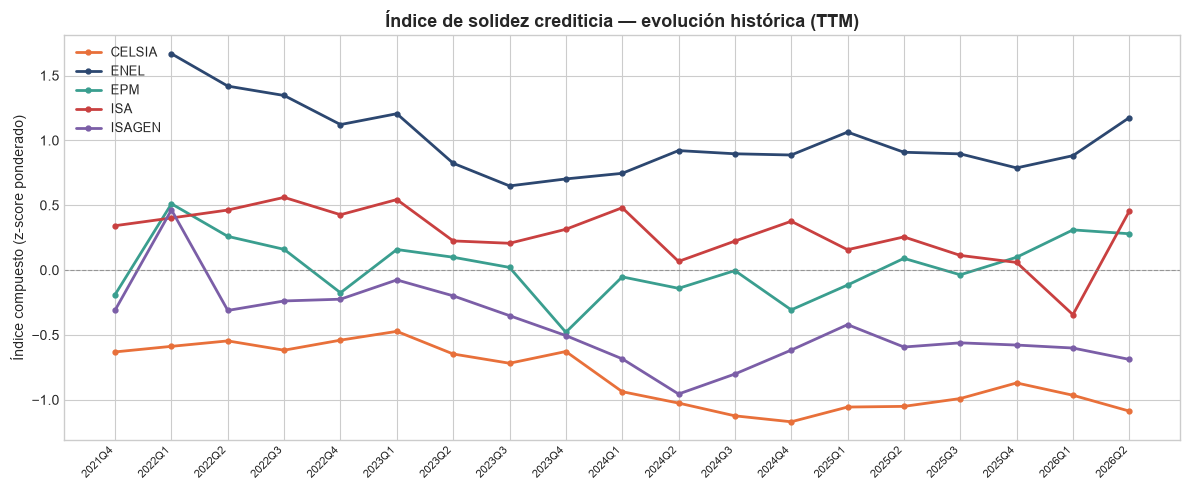

In [7]:
fig, ax = plt.subplots(figsize=(12, 5))

periodos = sorted(panel_ratios["periodo"].unique())
x_pos    = {p: i for i, p in enumerate(periodos)}

for emisor in EMISORES:
    sub = panel_ratios[panel_ratios["emisor"] == emisor].sort_values("periodo")
    ax.plot(
        [x_pos[p] for p in sub["periodo"]],
        sub["indice"],
        label=emisor,
        color=COLORS[emisor],
        linewidth=2,
        marker="o",
        markersize=3.5,
    )

ax.set_xticks(range(len(periodos)))
ax.set_xticklabels(periodos, rotation=45, ha="right", fontsize=8)
ax.axhline(0, color="gray", linewidth=0.8, linestyle="--", alpha=0.7)
ax.set_title("Índice de solidez crediticia — evolución histórica (TTM)", fontsize=13, fontweight="bold")
ax.set_ylabel("Índice compuesto (z-score ponderado)")
ax.legend(loc="upper left", framealpha=0.9, fontsize=9)
plt.tight_layout()
plt.savefig("../outputs/grafico1_evolucion_historica.png", dpi=150, bbox_inches="tight")
plt.show()

## Evolución histórica del índice

La gráfica permite identificar tendencias persistentes y puntos de inflexión más allá del último periodo. Conviene leerla en dos niveles:

**Nivel estructural (entre emisores):** ENEL se mantiene consistentemente separado hacia arriba, mientras CELSIA e ISAGEN permanecen por debajo de cero durante la mayor parte del periodo. Esto sugiere que la diferencia entre emisores refleja características estructurales de negocio —tipo de activo, nivel de regulación, política financiera— más que variación coyuntural.

**Nivel dinámico (dentro de cada emisor):** un deterioro sostenido de la línea puede reflejar acumulación de deuda nueva, caída de márgenes o presión sobre la liquidez. Una recuperación brusca en un trimestre, especialmente en ENEL, puede corresponder a un periodo con dato real de EBITDA (Q1) en lugar de un trimestre imputado.

**Advertencia metodológica:** la suavidad artificial de la serie de ENEL en los trimestres Q2–Q4 de cada año se debe a la imputación con margen constante; los movimientos reales interanuales sí reflejan la evolución de los ingresos observados.

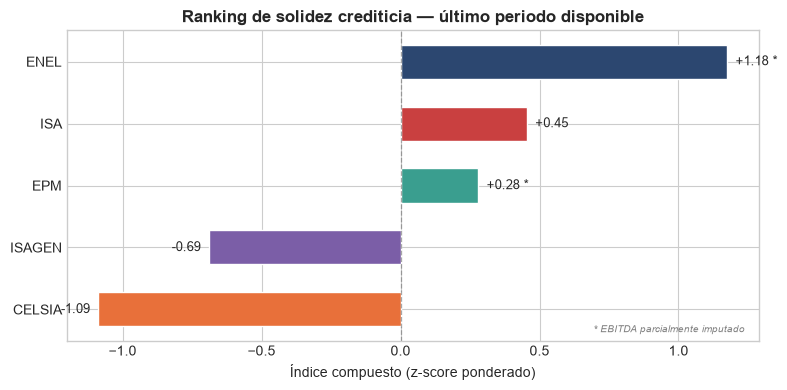

In [8]:
ultimo_rank = (
    panel_ratios.sort_values("periodo")
    .groupby("emisor")[["indice", "ebitda_imputado_ttm"]]
    .last()
    .reset_index()
    .sort_values("indice")
)

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(
    ultimo_rank["emisor"],
    ultimo_rank["indice"],
    color=[COLORS[e] for e in ultimo_rank["emisor"]],
    edgecolor="white",
    height=0.55,
)
ax.axvline(0, color="gray", linewidth=0.9, linestyle="--", alpha=0.7)
ax.set_title("Ranking de solidez crediticia — último periodo disponible", fontsize=12, fontweight="bold")
ax.set_xlabel("Índice compuesto (z-score ponderado)")

for bar, (_, row) in zip(bars, ultimo_rank.iterrows()):
    val = row["indice"]
    label = f"{val:+.2f}"
    if row["ebitda_imputado_ttm"]:
        label += " *"
    ax.text(
        val + (0.03 if val >= 0 else -0.03),
        bar.get_y() + bar.get_height() / 2,
        label,
        va="center",
        ha="left" if val >= 0 else "right",
        fontsize=9,
    )

ax.text(0.98, 0.02, "* EBITDA parcialmente imputado",
        transform=ax.transAxes, ha="right", va="bottom",
        fontsize=7.5, color="gray", style="italic")
plt.tight_layout()
plt.savefig("../outputs/grafico2_ranking.png", dpi=150, bbox_inches="tight")
plt.show()

## Ranking del último periodo

El ranking sintetiza la posición relativa de cada emisor en el trimestre más reciente disponible (2026Q2). Un valor positivo indica una posición por encima del promedio histórico del panel; negativo, por debajo.

**ENEL** lidera con amplio margen (+1.16), impulsado por bajo apalancamiento y alta cobertura. El asterisco indica que su EBITDA en este periodo es imputado, lo que debe tenerse en cuenta al interpretar el nivel absoluto.

**ISA** ocupa la segunda posición (+0.44), sostenida por liquidez y margen, aunque con apalancamiento elevado que la hace más vulnerable a choques operativos como se demostró en el stress test.

**EPM** se ubica cerca del promedio del panel (+0.26), con una posición equilibrada en todas las dimensiones.

**ISAGEN** (−0.69) y **CELSIA** (−1.09) presentan las posiciones más débiles. El principal factor diferenciador es la combinación de alto apalancamiento con baja cobertura de intereses, que deja poco margen ante un deterioro del entorno operativo.

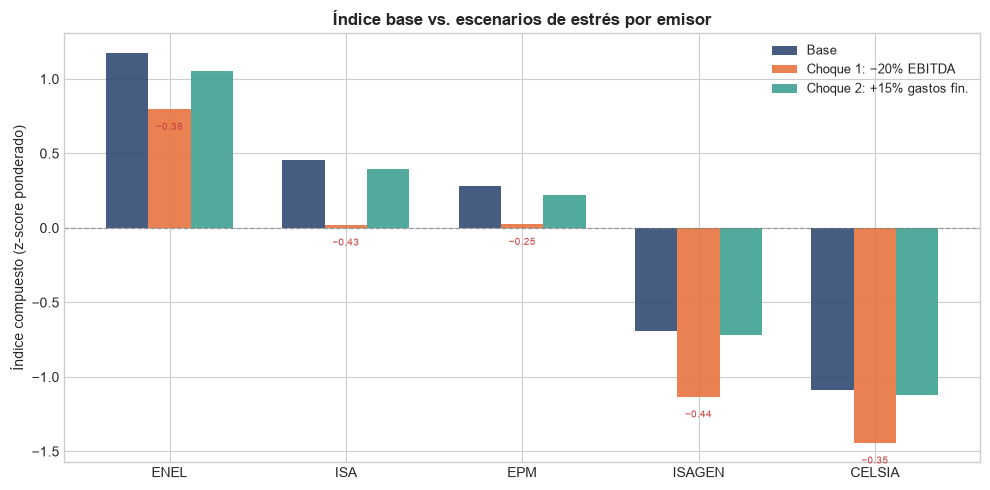

In [9]:
# Ordenar por índice base descendente para mejor lectura
orden = stress_ebitda.sort_values("indice_base", ascending=False)["emisor"].tolist()
stress_combined = stress_ebitda.merge(
    stress_fin[["emisor", "indice_stress_fin"]],
    on="emisor"
)
stress_combined = stress_combined.set_index("emisor").loc[orden].reset_index()

x     = np.arange(len(stress_combined))
width = 0.24

fig, ax = plt.subplots(figsize=(10, 5))
b1 = ax.bar(x - width,     stress_combined["indice_base"],          width, label="Base",                          color="#2C4770", alpha=0.88)
b2 = ax.bar(x,             stress_combined["indice_stress_ebitda"],  width, label="Choque 1: −20% EBITDA",         color="#E8703A", alpha=0.88)
b3 = ax.bar(x + width,     stress_combined["indice_stress_fin"],     width, label="Choque 2: +15% gastos fin.",    color="#3A9E8F", alpha=0.88)

ax.set_xticks(x)
ax.set_xticklabels(stress_combined["emisor"], fontsize=10)
ax.axhline(0, color="gray", linewidth=0.9, linestyle="--", alpha=0.7)
ax.set_title("Índice base vs. escenarios de estrés por emisor", fontsize=12, fontweight="bold")
ax.set_ylabel("Índice compuesto (z-score ponderado)")
ax.legend(fontsize=9, framealpha=0.9)

# Anotar colchón perdido bajo choque EBITDA
for i, row in stress_combined.iterrows():
    ax.annotate(
        f"−{row['colchon_ebitda']:.2f}",
        xy=(i, row["indice_stress_ebitda"]),
        xytext=(0, -15),
        textcoords="offset points",
        ha="center", fontsize=7.5, color="#C94040",
    )

plt.tight_layout()
plt.savefig("../outputs/grafico3_stress.png", dpi=150, bbox_inches="tight")
plt.show()

## Comparación base vs. escenarios de estrés

La gráfica muestra los tres estados de cada emisor: índice base, bajo choque operativo (−20% EBITDA) y bajo choque de tasas (+15% gastos financieros). Los números en rojo debajo de las barras naranjas indican el colchón perdido en el primer choque.

Las conclusiones principales son:

1. **El choque de EBITDA domina sobre el choque de tasas** para todos los emisores. La distancia entre la barra azul y la naranja supera ampliamente la distancia entre la azul y la verde, confirmando que el riesgo operativo es el canal de transmisión más relevante para este grupo.

2. **ISA e EPM convergen cerca de cero** bajo el choque de EBITDA, a pesar de tener índices base distintos. Esto refleja que sus posiciones crediticias, aunque sólidas en escenario base, tienen poca profundidad ante un choque operativo severo.

3. **ENEL mantiene el índice estresado más alto** en ambos choques, confirmando que su bajo apalancamiento actúa como amortiguador estructural.

4. **CELSIA e ISAGEN profundizan su posición negativa** en ambos escenarios, lo que refuerza la señal de fragilidad identificada en el análisis base.

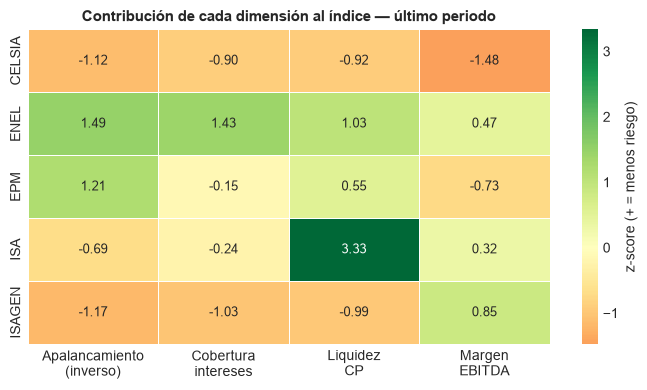

In [10]:
Z_COLS = ["z_deuda_ebitda", "z_cobertura_intereses", "z_liquidez_cp", "z_margen_ebitda"]
ultimo_z = (
    panel_ratios.sort_values("periodo")
    .groupby("emisor")[Z_COLS]
    .last()
    .loc[sorted(EMISORES)]
)
ultimo_z.index.name = None
ultimo_z.columns = ["Apalancamiento\n(inverso)", "Cobertura\nintereses", "Liquidez\nCP", "Margen\nEBITDA"]

fig, ax = plt.subplots(figsize=(7, 4))
sns.heatmap(
    ultimo_z,
    annot=True, fmt=".2f",
    cmap="RdYlGn", center=0,
    linewidths=0.5, ax=ax,
    cbar_kws={"label": "z-score (+ = menos riesgo)"},
    annot_kws={"size": 9},
)
ax.set_title("Contribución de cada dimensión al índice — último periodo", fontsize=11, fontweight="bold")
ax.set_xlabel("")
plt.tight_layout()
plt.savefig("../outputs/grafico4_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

In [11]:
# Construir tabla resumen del último periodo
ultimo_ratios = (
    ttm.sort_values("periodo")
    .groupby("emisor")[RATIOS]
    .last()
    .reset_index()
)

resumen = (
    stress_ebitda[["emisor", "indice_base", "indice_stress_ebitda", "colchon_ebitda"]]
    .merge(stress_fin[["emisor", "indice_stress_fin", "colchon_fin"]], on="emisor")
    .merge(ultimo_ratios, on="emisor")
    .sort_values("indice_base", ascending=False)
)

resumen.columns = [
    "Emisor",
    "Índice base", "Índice − EBITDA", "Colchón EBITDA",
    "Índice − Gastos fin.", "Colchón Gastos fin.",
    "Deuda/EBITDA", "Cobertura int.", "Liquidez CP", "Margen EBITDA",
]

pd.set_option("display.float_format", "{:.3f}".format)
print("Tabla resumen — último periodo disponible:")
print(resumen.to_string(index=False))

resumen.to_csv("../outputs/tabla_resumen.csv", index=False)
print("\nGuardada en ../outputs/tabla_resumen.csv")

Tabla resumen — último periodo disponible:
Emisor  Índice base  Índice − EBITDA  Colchón EBITDA  Índice − Gastos fin.  Colchón Gastos fin.  Deuda/EBITDA  Cobertura int.  Liquidez CP  Margen EBITDA
  ENEL        1.175            0.799           0.376                 1.051                0.124         1.225           5.963        1.842          0.472
   ISA        0.455            0.022           0.433                 0.396                0.059         4.429           2.830        3.668          0.450
   EPM        0.280            0.026           0.254                 0.218                0.062         1.633           2.981        1.463          0.288
ISAGEN       -0.689           -1.132           0.443                -0.717                0.028         5.150           1.338        0.245          0.531
CELSIA       -1.087           -1.441           0.354                -1.120                0.033         5.072           1.576        0.294          0.175

Guardada en ../outputs/tabla_res

## Conclusiones

El análisis identifica **tres perfiles crediticios diferenciados** dentro de los cinco emisores:

**Perfil sólido — ENEL:** presenta el menor apalancamiento del grupo (1.2x en el último periodo) y la mayor cobertura de intereses (6x). Su índice base supera a los demás por un margen amplio y se mantiene positivo incluso bajo el choque más severo. La principal limitación es que parte de su EBITDA histórico está imputado, lo que introduce incertidumbre sobre la magnitud exacta de su ventaja.

**Perfil intermedio — ISA y EPM:** posición crediticia razonable en escenario base, pero con colchones limitados ante choques operativos. ISA destaca por su liquidez, pero su apalancamiento de 4.4x la hace sensible a caídas de EBITDA. EPM muestra una posición más equilibrada. Ambas convergen cerca de cero bajo el choque de EBITDA del 20%, lo que sugiere que su fortaleza es sensible a la coyuntura operativa.

**Perfil frágil — ISAGEN y CELSIA:** combinan alto apalancamiento (4.8x y 4.4x respectivamente) con coberturas de intereses bajas (~1.9x y ~2.0x). Este patrón de doble riesgo —mucha deuda, poca holgura para cubrirla— es la señal de mayor atención del análisis. Bajo estrés, su posición se deteriora aún más, alejándose del territorio neutral.

**Limitaciones metodológicas:**
- La normalización por z-score es relativa al panel de cinco empresas. El índice mide posición relativa dentro del grupo, no probabilidad absoluta de incumplimiento.
- El EBITDA de ENEL está parcialmente imputado con un margen constante; los Q2–Q4 de cada año no reflejan variación estacional real.
- El universo de cinco emisores limita la potencia de la normalización. Una expansión del panel a emisores del RNVE con cambios de calificación permitiría construir un modelo logístico más robusto (fase 2 del proyecto).